In [1]:
import os
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import torch

def load_tensorboard_events(file_path):
    # Create an EventAccumulator to load the event file.
    # The 'size_guidance' argument can be used to control how many items to load for each type.
    ea = event_accumulator.EventAccumulator(
        file_path,
        size_guidance={
            'scalars': 1000,   # maximum number of scalar events to load per tag
            'images': 4,       # maximum number of image events to load per tag
            'histograms': 1,   # maximum number of histogram events to load per tag
            'compressedHistograms': 1,
            'audio': 1,
        }
    )
    ea.Reload()  # load events from file

    # Print available tags
    tags = ea.Tags()
    print("Available Tags:", tags)

    # For example, to print all scalar events for each scalar tag:
    if 'scalars' in tags:
        for tag in tags['scalars']:
            print(f"\nScalar values for tag: {tag}")
            events = ea.Scalars(tag)
            for event in events:
                print(f"Step: {event.step}, Value: {event.value}")
                

def load_tensorboard_metrics(file_path):
    ea = event_accumulator.EventAccumulator(
        file_path,
        size_guidance={
            'scalars': 100,   # maximum number of scalar events to load per tag
            'images': 4,       # maximum number of image events to load per tag
            'histograms': 1,   # maximum number of histogram events to load per tag
            'compressedHistograms': 1,
            'audio': 1,
        }
    )
    ea.Reload()  # load events from file
    tags = ea.Tags()
    metrics = tags['scalars']
    
    return_dict = {
        'best_model_epoch': None,
        'in-domain test metric (per sample)': None,
        'test metric (per sample)': None,
    }
    
    for tag in metrics:
        if 'in-domain test metric' in tag:
            return_dict['in-domain test metric (per sample)'] = ea.Scalars(tag)[0].value
            return_dict['best_model_epoch'] = ea.Scalars(tag)[0].step   
        elif 'test metric' in tag:
            return_dict['test metric (per sample)'] = ea.Scalars(tag)[0].value
    return return_dict  


def load_series_metrics(tensor_board_dir, model_metrics):
    unmatched_sub_fodlers = []
    sub_fodlers = os.listdir(tensor_board_dir)
    models = model_metrics.keys()
    for sub_folder in sub_fodlers:
        sub_folder_path = os.path.join(tensor_board_dir, sub_folder)
        files = os.listdir(sub_folder_path)
        # find the key that in the sub_folder
        key = None
        for model in models:
            if model in sub_folder:
                key = model
                break
        if key is None:
            unmatched_sub_fodlers.append(sub_folder)
            continue
        for file in files:
            if file.startswith("events.out.tfevents"):
                file_path = os.path.join(sub_folder_path, file)
                metrics = load_tensorboard_metrics(file_path)
                metrics['sub_folder'] = sub_folder
                model_metrics[key].append(metrics)
    return model_metrics, unmatched_sub_fodlers


def MPJPE_2D(predicts, labels, per_sample = True):
    # if the shape of the predicts and labels are : (batch_size, num_joints * 2)
    # reshape the predicts and labels to (batch_size, num_joints, dim)
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = predicts.reshape(predicts.shape[0], -1, 2)
    labels = labels.reshape(labels.shape[0], -1, 2)
    per_sample_mpjpe = np.mean(np.abs(np.linalg.norm(predicts - labels, axis=2)), axis=1)
    if per_sample:
        return per_sample_mpjpe
    return np.mean(per_sample_mpjpe, axis=0)

def MPJPE_3D(predicts, labels, per_sample = True):
    # if the shape of the predicts and labels are : (batch_size, num_joints * 3) 
    # reshape the predicts and labels to (batch_size, num_joints, dim)
    if isinstance(predicts, torch.Tensor):
        predicts = predicts.detach().cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu().numpy()
    predicts = predicts.reshape(predicts.shape[0], -1, 3)
    labels = labels.reshape(labels.shape[0], -1, 3)
    per_sample_mpjpe = np.mean(np.linalg.norm(predicts - labels, axis=2), axis=1)
    # if there is any value less than 0, print the index
    if np.any(per_sample_mpjpe < 0):
        print("less than 0")
        print(np.where(per_sample_mpjpe < 0))
    if per_sample:
        return per_sample_mpjpe
    return np.mean(per_sample_mpjpe, axis=0)

## Classification tasks

### Widar3G6

In [2]:
all_results_folder = 'logs/widar3G6/'

results_files = [
    'widar3G6_swin_t_swin_t_0128162053_indomain_test',
    'widar3G6_complex_swin_t_complex_swin_t_0418135844_indomain_test',
    'widar3G6_complex_ampha_swin_t_complex_ampha_swin_t_0421225820_indomain_test',
]

model_names = [
    'Swin-T', 
    'Real+Imaginary Complex Swin-T',
    'Phase+Amplitude Complex Swin-T',
    ]

w3G6_indomain_accuracy_list = []

for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        w3G6_indomain_accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in w3G6_indomain_accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc)*100)
    std_acc.append(np.std(acc)*100)
# print(mean_acc)
# print(std_acc)

dataset1_acc = mean_acc
dataset1_acc_std = std_acc

print("indomain results")
for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')
    


results_files = [
    'widar3G6_swin_t_swin_t_0128162053',
    'widar3G6_complex_swin_t_complex_swin_t_0418135844',
    'widar3G6_complex_ampha_swin_t_complex_ampha_swin_t_0421225820',
]

model_names = [
    'Swin-T', 
    'Real+Imaginary Complex Swin-T',
    'Phase+Amplitude Complex Swin-T',
    ]


W3G6_cross_domain_accuracy_list = []

for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        W3G6_cross_domain_accuracy_list.append(results['metrics'])


mean_acc = []
std_acc = []

for acc in W3G6_cross_domain_accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc)*100)
    std_acc.append(np.std(acc)*100)
dataset2_acc = mean_acc
dataset2_acc_std = std_acc

print("cross-domain results")
for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.4f} ± {std_acc[index]:.4f}')
    
# the average of dataset1 and dataset2
dataset12_acc = [(dataset1_acc[i] + dataset2_acc[i]) / 2 for i in range(len(dataset1_acc))]
dataset12_acc_std = [(dataset1_acc_std[i] + dataset2_acc_std[i]) / 2 for i in range(len(dataset1_acc_std))]

print("average of in-domain and cross-domain results")
for index, name in enumerate(model_names):
    print(f'{name}: {dataset12_acc[index]:.4f} ± {dataset12_acc_std[index]:.4f}')

indomain results
Swin-T: 89.4252 ± 5.0501
Real+Imaginary Complex Swin-T: 16.2946 ± 9.3697
Phase+Amplitude Complex Swin-T: 17.2433 ± 8.3622
cross-domain results
Swin-T: 79.0654 ± 14.8755
Real+Imaginary Complex Swin-T: 16.7218 ± 37.1810
Phase+Amplitude Complex Swin-T: 16.7173 ± 37.1593
average of in-domain and cross-domain results
Swin-T: 84.2453 ± 9.9628
Real+Imaginary Complex Swin-T: 16.5082 ± 23.2753
Phase+Amplitude Complex Swin-T: 16.9803 ± 22.7607


### UWB activity (OperaNet dataset)

In [3]:
all_results_folder = 'logs/OperaNet/UWB1/'

UWB1_overall_acc = None
UWB1_overall_acc_std = None

results_files = [
    'OPERAnet_UWB1_swin_t_swin_t_0127165251',
    'OPERAnet_UWB1_complex_swin_t_complex_swin_t_0417160628',
    'OPERAnet_UWB1_complex_ampha_swin_t_complex_ampha_swin_t_0421114419',
    
]

model_names = [
    'Swin-T', 
    'Real+Imaginary Complex Swin-T',
    'Phase+Amplitude Complex Swin-T',
    ]


UWB1_accuracy_list = []

for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        UWB1_accuracy_list.append(results['metrics'])


mean_acc = []
std_acc = []

for acc in UWB1_accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))


UWB1_overall_acc = np.array(mean_acc)*100
UWB1_overall_acc_std = np.array(std_acc)*100

print("UWB1 results")
for index, name in enumerate(model_names):
    print(f'{name}: {UWB1_overall_acc[index]:.2f} ± {UWB1_overall_acc_std[index]:.2f}')
    
    
    

all_results_folder = 'logs/OperaNet/UWB2/'

UWB2_overall_acc = None
UWB2_overall_acc_std = None


results_files = [
    'OPERAnet_UWB2_swin_t_swin_t_0127162959',
    'OPERAnet_UWB2_complex_swin_t_complex_swin_t_0417170031',
    'OPERAnet_UWB2_complex_ampha_swin_t_complex_ampha_swin_t_0421115109',
]

model_names = [
    'Swin-T', 
    'Real+Imaginary Complex Swin-T',
    'Phase+Amplitude Complex Swin-T',
    ]


UWB2_accuracy_list = []

for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        UWB2_accuracy_list.append(results['metrics'])


mean_acc = []
std_acc = []

for acc in UWB2_accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))

UWB2_overall_acc = np.array(mean_acc)*100
UWB2_overall_acc_std = np.array(std_acc)*100

print("UWB2 overall results")
for index, name in enumerate(model_names):
    print(f'{name}: {UWB2_overall_acc[index]:.4f} ± {UWB2_overall_acc_std[index]:.4f}')


dataset4_acc = (np.array(UWB1_overall_acc) + np.array(UWB2_overall_acc)) / 2
dataset4_acc_std = (np.array(UWB1_overall_acc_std) + np.array(UWB2_overall_acc_std)) / 2

print('UWB overall results:')
for index, name in enumerate(model_names):
    print(f'{name}: {dataset4_acc[index]:.2f} ± {dataset4_acc_std[index]:.2f}')
    

UWB1 results
Swin-T: 66.07 ± 9.94
Real+Imaginary Complex Swin-T: 57.14 ± 13.54
Phase+Amplitude Complex Swin-T: 69.20 ± 15.57
UWB2 overall results
Swin-T: 67.9688 ± 8.3780
Real+Imaginary Complex Swin-T: 65.2778 ± 8.8932
Phase+Amplitude Complex Swin-T: 70.1389 ± 7.6704
UWB overall results:
Swin-T: 67.02 ± 9.16
Real+Imaginary Complex Swin-T: 61.21 ± 11.22
Phase+Amplitude Complex Swin-T: 69.67 ± 11.62


### Wifi Gait recognition 

In [4]:
all_results_folder = 'logs/widarGait/'


results_files = [
    'widarGait_swin_t_swin_t_0218093555',
    'widarGait_complex_swin_t_complex_swin_t_0419094546',
    'widarGait_complex_ampha_swin_t_complex_ampha_swin_t_0420204229',
]

model_names = [
    'Swin-T', 
    'Real+Imaginary Complex Swin-T',
    'Phase+Amplitude Complex Swin-T',
    ]

gait_accuracy_list = []
for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        gait_accuracy_list.append(results['metrics'])

mean_acc = []
std_acc = []

for acc in gait_accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc)*100)
    std_acc.append(np.std(acc)*100)
    
dataset5_acc = mean_acc
dataset5_acc_std = std_acc

print("Gait recognition results:")
for index, name in enumerate(model_names):
    print(f'{name}: {mean_acc[index]:.2f} ± {std_acc[index]:.2f}')
    

Gait recognition results:
Swin-T: 96.86 ± 3.11
Real+Imaginary Complex Swin-T: 14.17 ± 8.67
Phase+Amplitude Complex Swin-T: 33.27 ± 11.49


### Fig. 16. Swin-T vs. Complex Swin-T on classification tasks.

[96.85773480662984, 84.24531353709281, 67.02008928571428]
[14.174723756906078, 16.50820420198101, 61.21031746031746]
[33.27002762430939, 16.980300820739302, 69.66765873015873]


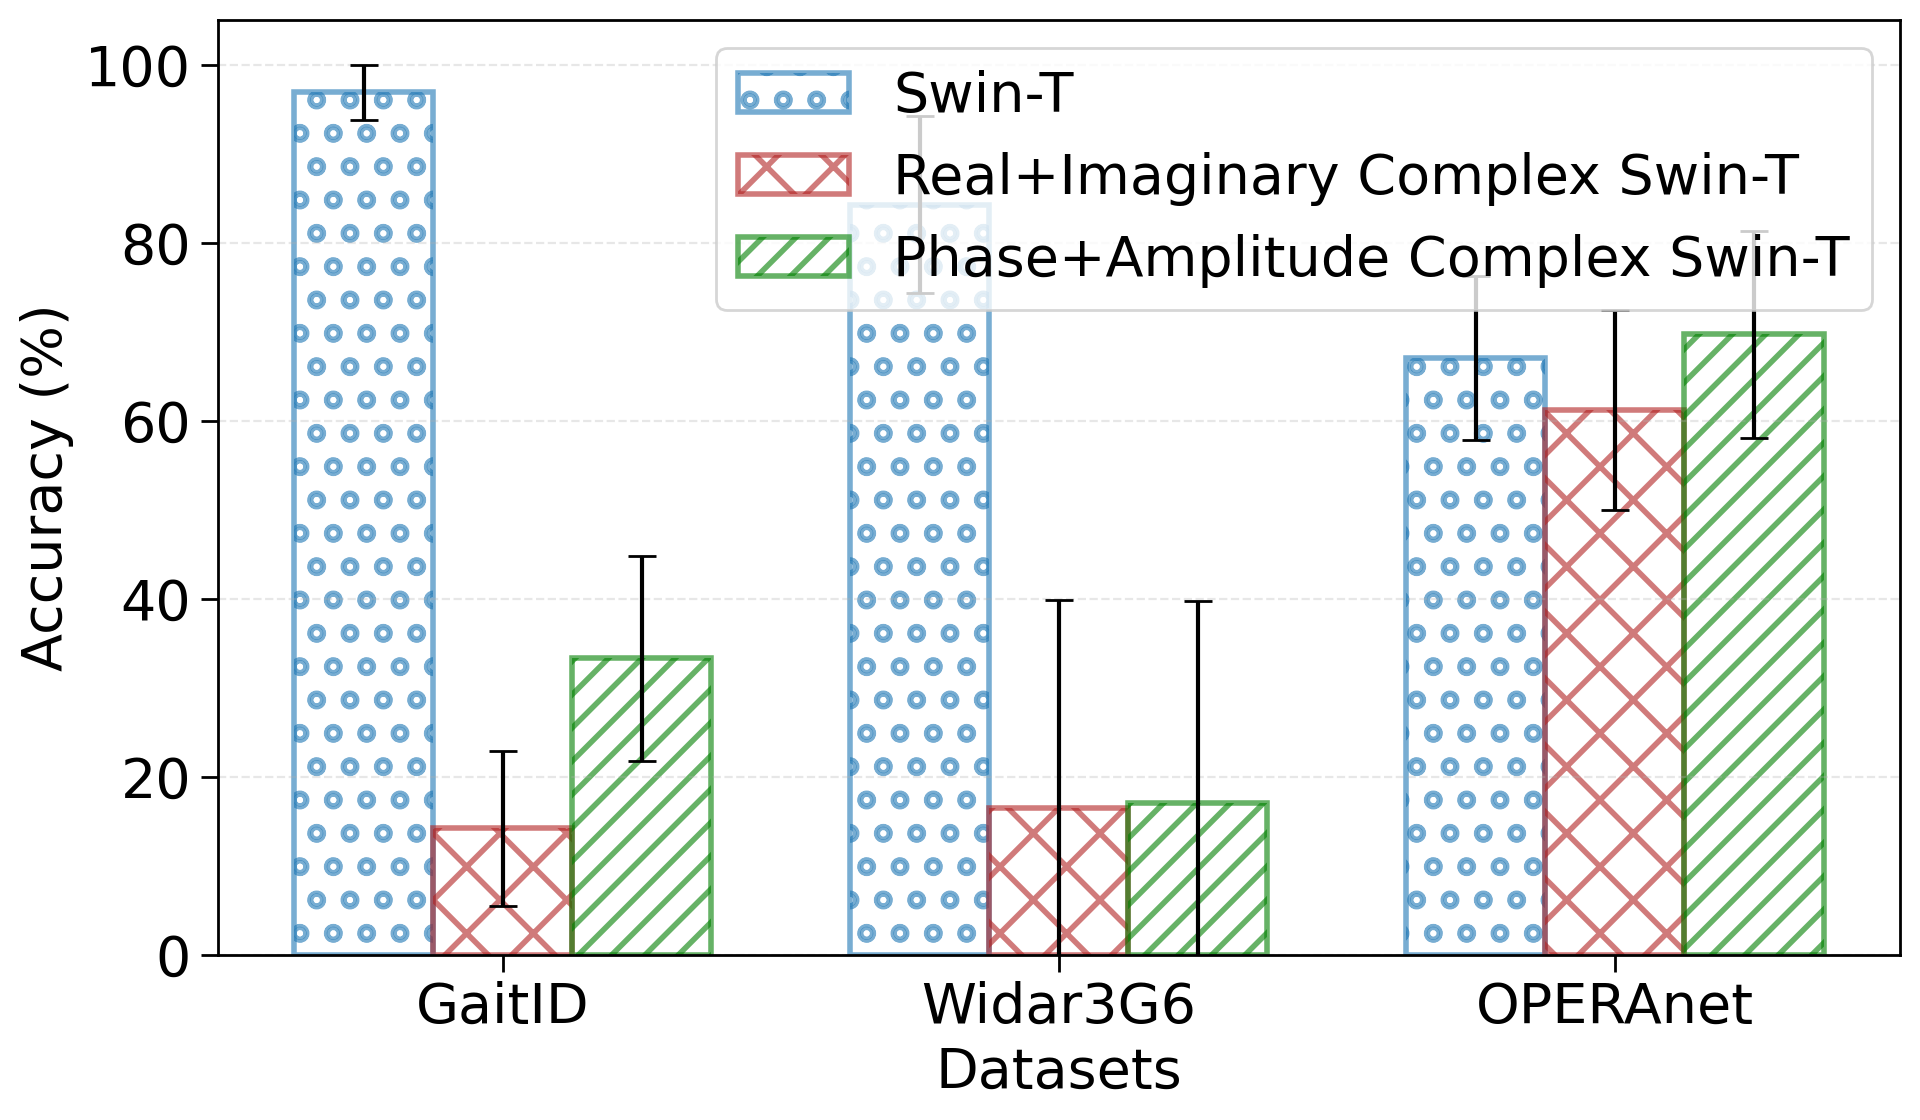

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib as mpl


SwinT_results_acc_list = [dataset5_acc[0], dataset12_acc[0], dataset4_acc[0]]
SwinT_results_acc_std_list = [dataset5_acc_std[0], dataset12_acc_std[0], dataset4_acc_std[0]]

RealImg_results_acc_list = [dataset5_acc[1], dataset12_acc[1], dataset4_acc[1]]
RealImg_results_acc_std_list = [dataset5_acc_std[1], dataset12_acc_std[1], dataset4_acc_std[1]]

PhaseAmp_results_acc_list = [dataset5_acc[2], dataset12_acc[2], dataset4_acc[2]]
PhaseAmp_results_acc_std_list = [dataset5_acc_std[2], dataset12_acc_std[2], dataset4_acc_std[2]]

print(SwinT_results_acc_list)
print(RealImg_results_acc_list)
print(PhaseAmp_results_acc_list)

# Create a visualization to compare CRATE vs RF-CRATE
dataset_names = ['GaitID', 'Widar3G6', 'OPERAnet']
x = np.arange(len(dataset_names))
width = 0.25

plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 20}) 


fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

# Update font settings
plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 20}) 

# Create bars
mpl.rcParams['hatch.linewidth'] = 2
rects1 = ax.bar(x - width, SwinT_results_acc_list, width, label='Swin-T', 
                yerr=SwinT_results_acc_std_list, capsize=5,facecolor='none', 
                hatch='o', edgecolor='tab:blue', linewidth=2, alpha=0.6)
rects2 = ax.bar(x, RealImg_results_acc_list, width, label='Real+Imaginary Complex Swin-T', 
                yerr=RealImg_results_acc_std_list, capsize=5, facecolor='none', 
                hatch='X', edgecolor='firebrick', linewidth=2, alpha=0.6)
rects3 = ax.bar(x + width, PhaseAmp_results_acc_list, width, label='Phase+Amplitude Complex Swin-T', 
                yerr=PhaseAmp_results_acc_std_list, capsize=5, facecolor='none', 
                hatch='//', edgecolor='green', linewidth=2, alpha=0.6)

# Configure tick marks
ax.tick_params(axis='both', direction='out', length=6, width=1)
ax.tick_params(axis='x', bottom=True)
ax.tick_params(axis='y', left=True)

# Set labels and limits
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x)
ax.set_xticklabels(dataset_names, rotation=0, ha='center')
ax.set_ylim(0, 105)

# Grid settings
plt.grid(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Labels and legend
plt.xlabel('Datasets')
ax.legend(loc='upper right')

ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)

# Layout
fig.tight_layout()
# plt.savefig("figures/V2_classification_swint_vs_complex_swint" + ".pdf",dpi=200,bbox_inches = 'tight')

plt.show()

## Regression tasks

### WiFi pose

In [7]:
all_results_folder = 'logs/OctonetMini/'

results_files = [
    'OctonetMini_swin_t_swin_t_0207222621',
    'OctonetMini_complex_swin_t_complex_swin_t_0417202339',
    'OctonetMini_complex_ampha_swin_t_complex_ampha_swin_t_0421213845'
]

model_names = [
    'Swin-T', 
    'Real+Imaginary Complex Swin-T',
    'Phase+Amplitude Complex Swin-T',
    ]


metric_list = []
predicts_list = []
labels_list = []

for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        metric_list.append(results['metrics'])
        predicts_list.append(results['predicts'])
        labels_list.append(results['labels'])


mpjpe_list = []
for predicts, labels in zip(predicts_list, labels_list):
    mpjpe_temp = []
    for i in range(len(predicts)):
        mpjpe = MPJPE_3D(predicts[i], labels[i])  # one batch
        mpjpe_temp += mpjpe.tolist()
    mpjpe_list.append(mpjpe_temp)

octonet_mini_mpjpe_list = np.array(mpjpe_list)/100
mpjpe_mean = np.array([np.mean(mpjpe) for mpjpe in mpjpe_list])
std_mpjpe = np.array([np.std(mpjpe) for mpjpe in mpjpe_list])
for index, name in enumerate(model_names):
    print(f'{name}: {mpjpe_mean[index]/10:.2f} ± {std_mpjpe[index]/10:.2f}')


Swin-T: 28.70 ± 26.23
Real+Imaginary Complex Swin-T: 41.63 ± 20.95
Phase+Amplitude Complex Swin-T: 28.56 ± 26.35


### WiFi RPI

In [8]:
all_results_folder = 'logs/RPI/'

results_files =[
    'RPI_swin_t_swin_t_0317220225_indomain_test',
    'RPI_complex_swin_t_complex_swin_t_0417170419_indomain_test',
    'RPI_complex_ampha_swin_t_complex_ampha_swin_t_0421214301_indomain_test'
    ]

model_names = [
    'Swin-T', 
    'Real+Imaginary Complex Swin-T',
    'Phase+Amplitude Complex Swin-T',
    ]


bpme_list = []  # beat per minute error

for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        bpme_list.append(results['metrics'])


mean_bpme = []
std_bpme = []

for bpme in bpme_list:
    bpme = np.array(bpme)
    mean_bpme.append(np.mean(bpme))
    std_bpme.append(np.std(bpme))

rpi_bpme_list = bpme_list
for index, name in enumerate(model_names):
    print(f'{name}: {mean_bpme[index]:.2f} ± {std_bpme[index]:.2f}')



Swin-T: 2.44 ± 0.86
Real+Imaginary Complex Swin-T: 2.45 ± 0.88
Phase+Amplitude Complex Swin-T: 2.44 ± 0.75


### mmWave pose (HuPR)

In [ ]:
all_results_folder = 'logs/HuPR/'

indomain_mpjpe = None
indomain_mpjpe_std = None

crossdomain_mpjpe = None
crossdomain_mpjpe_std = None


# this part is the cross-domain 
results_files = [
    'HuPR_swin_t_swin_t_0219044545',
    'HuPR_complex_swin_t_complex_swin_t_0417171558',
    'HuPR_complex_ampha_swin_t_complex_ampha_swin_t_0421164002',
]

model_names = [
    'Swin-T', 
    'Real+Imaginary Complex Swin-T',
    'Phase+Amplitude Complex Swin-T',
    ]

metric_list = []
predicts_list = []
labels_list = []

for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        metric_list.append(results['metrics'])
        predicts_list.append(results['predicts'])
        labels_list.append(results['labels'])
        

mpjpe_list = []
for predicts, labels in zip(predicts_list, labels_list):
    mpjpe_temp = []
    for i in range(len(predicts)):
        mpjpe = MPJPE_2D(predicts[i], labels[i])  # one batch
        mpjpe_temp += mpjpe.tolist()
    mpjpe_list.append(mpjpe_temp)

mpjpe_mean = np.array([np.mean(mpjpe) for mpjpe in mpjpe_list])
mpjpe_std = np.array([np.std(mpjpe) for mpjpe in mpjpe_list])

crossdomain_mpjpe = mpjpe_mean
crossdomain_mpjpe_std = mpjpe_std

hupr_cross_domain_mpjpe_list = [np.array(ele)/10 for ele in mpjpe_list]

results_files = [
    'HuPR_swin_t_swin_t_0219044545_indomain_test',
    'HuPR_complex_swin_t_complex_swin_t_0417171558_indomain_test',
    'HuPR_complex_ampha_swin_t_complex_ampha_swin_t_0421164002_indomain_test'
]

model_names = [
    'Swin-T', 
    'Real+Imaginary Complex Swin-T',
    'Phase+Amplitude Complex Swin-T',
    ]

metric_list = []
predicts_list = []
labels_list = []

for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        metric_list.append(results['metrics'])
        predicts_list.append(results['predicts'])
        labels_list.append(results['labels'])
        

mpjpe_list = []
for predicts, labels in zip(predicts_list, labels_list):
    mpjpe_temp = []
    for i in range(len(predicts)):
        mpjpe = MPJPE_2D(predicts[i], labels[i])  # one batch
        mpjpe_temp += mpjpe.tolist()
    mpjpe_list.append(mpjpe_temp)

mpjpe_mean = np.array([np.mean(mpjpe) for mpjpe in mpjpe_list])
mpjpe_std = np.array([np.std(mpjpe) for mpjpe in mpjpe_list])

indomain_mpjpe = mpjpe_mean
indomain_mpjpe_std = mpjpe_std

hupr_indomain_mpje_list = [np.array(ele)/10 for ele in mpjpe_list]


overall_mpjpe = (indomain_mpjpe + crossdomain_mpjpe) / 2
overall_mpjpe_std = (indomain_mpjpe_std + crossdomain_mpjpe_std) / 2


print("overall results")
for index, name in enumerate(model_names):
    print(f'{name}: {overall_mpjpe[index]:.2f} ± {overall_mpjpe_std[index]:.2f}')


overall results
Swin-T: 10.61 ± 6.02
Real+Imaginary Complex Swin-T: 24.90 ± 11.91
Phase+Amplitude Complex Swin-T: 9.20 ± 6.19


### Fig. 17. Swin-T vs. Complex Swin-T on regression tasks

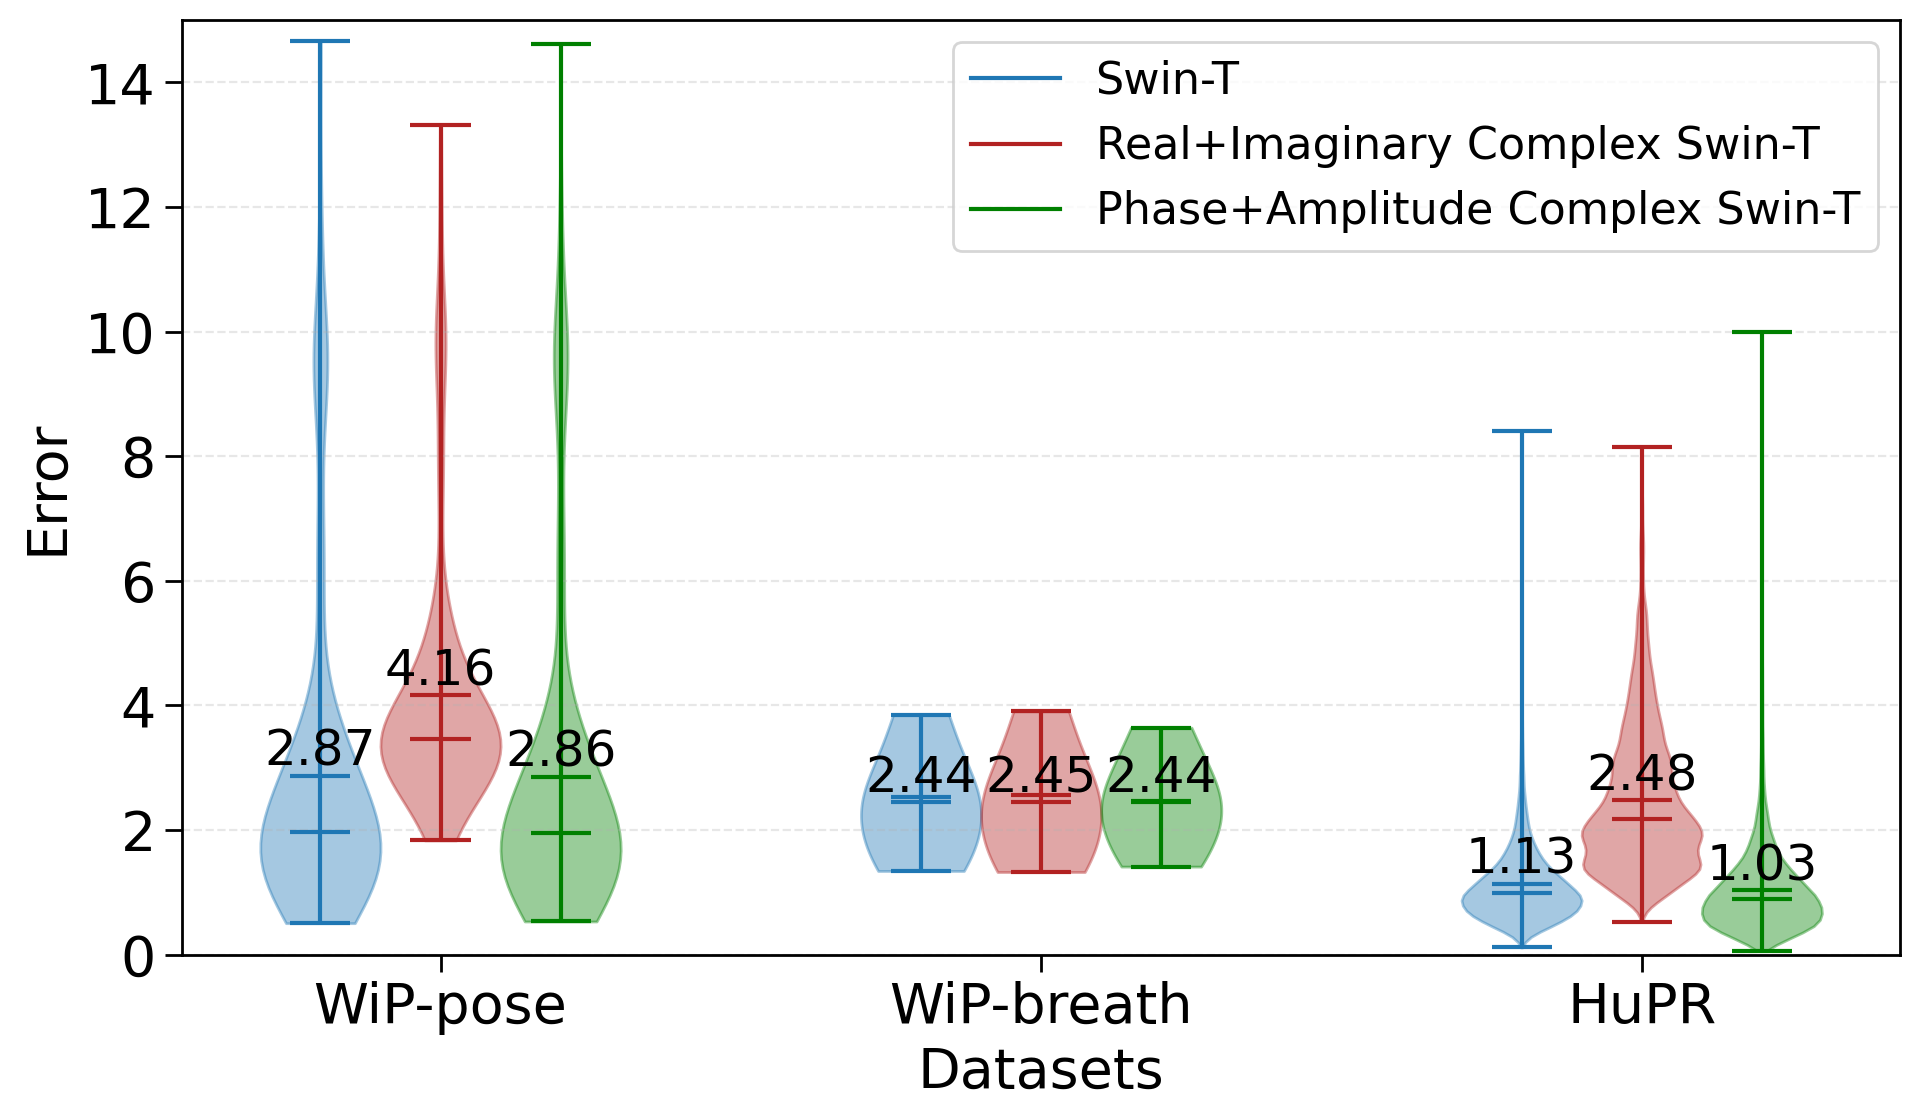

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib as mpl

swint_error_lists = [
    octonet_mini_mpjpe_list[0],
    rpi_bpme_list[0],
    hupr_cross_domain_mpjpe_list[0].tolist() + hupr_indomain_mpje_list[0].tolist(),
]

real_img_error_lists = [
    octonet_mini_mpjpe_list[1],
    rpi_bpme_list[1],
    hupr_cross_domain_mpjpe_list[1].tolist()  + hupr_indomain_mpje_list[1].tolist() ,
]

phase_amp_error_lists = [
    octonet_mini_mpjpe_list[2],
    rpi_bpme_list[2],
    hupr_cross_domain_mpjpe_list[2].tolist()  + hupr_indomain_mpje_list[2].tolist() ,
]

# First, organize the data for plotting
import pandas as pd

# Create lists to store all data points
all_data = []

# Process each dataset
dataset_names = ['WiP-pose', 'WiP-breath', 'HuPR']


for i, dataset in enumerate(swint_error_lists):
    for error in dataset:
        all_data.append({
            'Error': error ,  # Convert to percentage
            'Model': 'Swin-T',
            'Dataset': dataset_names[i]
        })


for i, dataset in enumerate(real_img_error_lists):
    for error in dataset:
        all_data.append({
            'Error': error,  # Convert to percentage
            'Model': 'Real+Imaginary Complex Swin-T',
            'Dataset': dataset_names[i]
        })


for i, dataset in enumerate(phase_amp_error_lists):
    for error in dataset:
        all_data.append({
            'Error': error,  # Convert to percentage
            'Model': 'Phase+Amplitude Complex Swin-T',
            'Dataset': dataset_names[i]
        })

# Create DataFrame
df = pd.DataFrame(all_data)

# print(df)

# Calculate mean values for each model and dataset
mean_values = df.groupby(['Dataset', 'Model'])['Error'].mean().reset_index()


# Set figure parameters
plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 20}) 

# Create figure
plt.figure(figsize=(10, 6), dpi=200)


# Get current axis
ax = plt.gca()

# Make the box outline black and visible
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['left'].set_linewidth(1.0)
ax.spines['right'].set_linewidth(1.0)

# Define colors
colors = {'Swin-T': 'tab:blue', 'Real+Imaginary Complex Swin-T': 'firebrick', 'Phase+Amplitude Complex Swin-T': 'green'}

# Create violin plot using matplotlib
positions = np.arange(len(dataset_names))
parts = []

for i, model in enumerate(['Swin-T', 'Real+Imaginary Complex Swin-T', 'Phase+Amplitude Complex Swin-T']):
    model_data = [df[(df['Dataset'] == dataset) & (df['Model'] == model)]['Error'].values 
                 for dataset in dataset_names]
    
    # Position offset for split violin plot
    # pos = positions + (0.15 if i == 1 else -0.15)
    if i == 0:
        pos = positions - 0.2
    elif i == 1:
        pos = positions 
    elif i == 2:
        pos = positions + 0.2
    
    # Create violin plot
    parts.append(plt.violinplot(model_data, positions=pos, widths=0.2,
                               showmeans=True, showextrema=True, showmedians=True,
                               ))
    
    # Customize violin appearance
    for pc in parts[i]['bodies']:
        pc.set_facecolor(colors[model])  # Set transparent fill
        pc.set_edgecolor(colors[model])  # Set edge color
        pc.set_alpha(0.4)
    
    # Customize other elements
    parts[i]['cmeans'].set_color(colors[model])
    parts[i]['cmins'].set_color(colors[model])
    parts[i]['cmaxes'].set_color(colors[model])
    parts[i]['cbars'].set_color(colors[model])
    parts[i]['cmedians'].set_color(colors[model])

# Add mean value annotations
for i, dataset in enumerate(dataset_names):
    for j, model in enumerate(['Swin-T', 'Real+Imaginary Complex Swin-T', 'Phase+Amplitude Complex Swin-T']):
        mean_val = mean_values[(mean_values['Dataset'] == dataset) & 
                              (mean_values['Model'] == model)]['Error'].values[0]
        
        # x_pos = i + (-0.3 if j == 0 else 0.3)
        if j == 0:
            x_pos = i -0.2
        elif j == 1:
            x_pos = i 
        elif j == 2:
            x_pos = i + 0.2
        
        # plt.text(x_pos, mean_val, f'{mean_val:.2f}', 
        #         ha='center', va='bottom', fontweight='bold', fontsize=14,
        #         color='darkblue' if j == 0 else 'darkred')
        plt.text(x_pos, mean_val, f'{mean_val:.2f}', 
                ha='center', va='bottom', 
                # fontweight='bold',
                fontsize=18,
                color='black')

# Customize plot appearance

# Configure tick marks
ax.tick_params(axis='both', direction='out', length=6, width=1)
ax.tick_params(axis='x', bottom=True)
ax.tick_params(axis='y', left=True)

plt.grid(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xlabel('Datasets')
plt.ylabel('Error')
plt.ylim(0, 15)

# Set x-axis ticks
plt.xticks(positions, dataset_names)

# Add legend
legend_elements = [plt.Line2D([0], [0], color=colors['Swin-T'], label='Swin-T'),
                  plt.Line2D([0], [0], color=colors['Real+Imaginary Complex Swin-T'], label='Real+Imaginary Complex Swin-T'),
                  plt.Line2D([0], [0], color=colors['Phase+Amplitude Complex Swin-T'], label='Phase+Amplitude Complex Swin-T')]
plt.legend(handles=legend_elements, fontsize=16, loc='upper right')

plt.tight_layout()
# plt.savefig("figures/V2_regression_swint_vs_complex_swint.pdf", dpi=200, bbox_inches='tight')
plt.show()